In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
##Hiing the warnings
import tensorflow as tf
import logging

tf.get_logger().setLevel(logging.ERROR)

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory("PlantVillage",
                                                    shuffle = True,
                                                    image_size = (IMAGE_SIZE,IMAGE_SIZE),
                                                    batch_size = BATCH_SIZE
                                                   )

Found 2152 files belonging to 3 classes.


In [5]:
class_name = dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset)

68

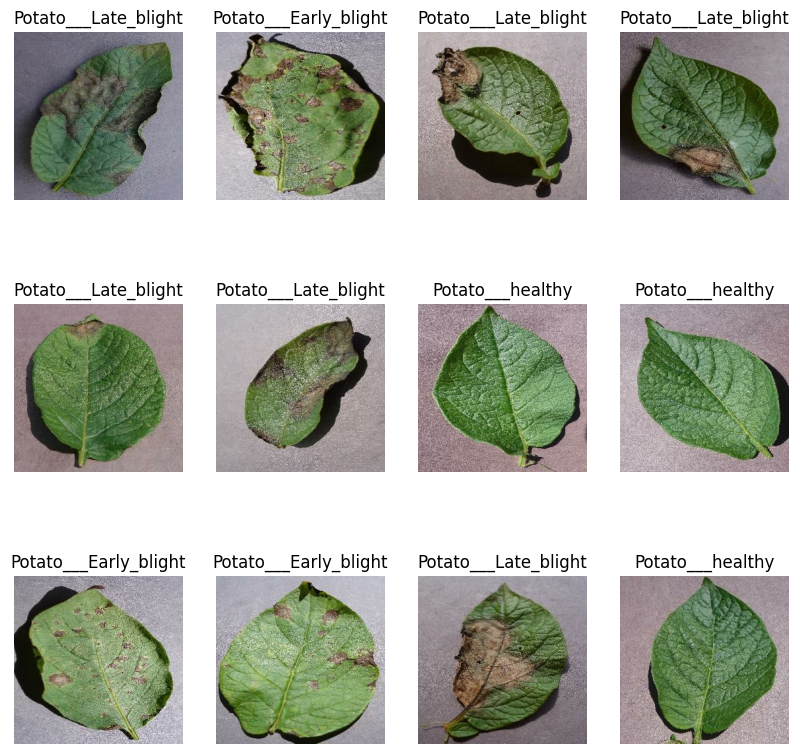

In [7]:
plt.figure(figsize = (10, 10))
for image_batch, label_batch in dataset.take(1):
    #print(image_batch[0].numpy())
    #print(image_batch[0].shape)
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))  ##Converted float to int
        plt.title(class_name[label_batch[i]])
        plt.axis("off") ##removed axis numbers

80% ==> training
20% ==> 10% validation, 10% test

'''at the end of every epochs we do validation once we have final model then we use test dataset'''

In [8]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [9]:
train_ds = dataset.take(54)
len(train_ds)

54

In [10]:
test_ds = dataset.skip(54)  ##arr[54: ]
len(test_ds)

14

In [11]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [12]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [13]:
def get_dataset_partition_tf(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 10000):
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds = ds.shuffle(shuffle_size, seed = 12)
    train_size = int(train_split*ds_size)
    val_size = int(val_split* ds_size)
    
    train_ds = ds.take(train_size)
    
    val_ds = ds.skip(train_size).take(val_size)
    
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [14]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [15]:
len(train_ds)

54

In [16]:
len(val_ds)

6

In [17]:
len(test_ds)

8

In [18]:
train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
## prefetch will load next set of batch from disk that will improve performance
## tnsorflow dynamically desides the optimal number of batches to prefetch
val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)


<PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [19]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
]) 

In [20]:
#Data Augumentation
data_augumentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    
])

In [21]:
input_shape = (BATCH_SIZE, IMAGE_SIZE,IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augumentation,
    layers.Conv2D(32, (3,3) ,activation = 'relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(64, activation = 'relu'),
    layers.Dense(n_classes, activation = 'softmax')
        
])

model.build(input_shape = input_shape)

In [22]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

In [23]:
model.compile(
    optimizer = 'adam',
    loss = 'SparseCategoricalCrossentropy',
    metrics = ['accuracy']
)

In [24]:
history = model.fit(
    train_ds, 
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data = val_ds
)

Epoch 1/50
54/54 [==============================] - 24s 244ms/step - loss: 0.9011 - accuracy: 0.4906 - val_loss: 0.9543 - val_accuracy: 0.4167
Epoch 2/50
54/54 [==============================] - 11s 178ms/step - loss: 0.7435 - accuracy: 0.6455 - val_loss: 0.6532 - val_accuracy: 0.7083
Epoch 3/50
54/54 [==============================] - 11s 178ms/step - loss: 0.5482 - accuracy: 0.7714 - val_loss: 0.6533 - val_accuracy: 0.6875
Epoch 4/50
54/54 [==============================] - 10s 175ms/step - loss: 0.4419 - accuracy: 0.8316 - val_loss: 0.3785 - val_accuracy: 0.8646
Epoch 5/50
54/54 [==============================] - 10s 174ms/step - loss: 0.2930 - accuracy: 0.8903 - val_loss: 0.3892 - val_accuracy: 0.8125
Epoch 6/50
54/54 [==============================] - 10s 172ms/step - loss: 0.2439 - accuracy: 0.9120 - val_loss: 0.6261 - val_accuracy: 0.7865
Epoch 7/50
54/54 [==============================] - 10s 174ms/step - loss: 0.2259 - accuracy: 0.9102 - val_loss: 0.4544 - val_accuracy: 0.8490

In [25]:
scores = model.evaluate(test_ds)

8/8 [==============================] - 1s 34ms/step - loss: 0.0398 - accuracy: 0.9844


In [26]:
scores

[0.039804793894290924, 0.984375]

In [27]:
history

In [28]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [29]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [30]:
history.history['accuracy'][40:]

[0.9823943376541138,
 0.98591548204422,
 0.9806337952613831,
 0.9929577708244324,
 0.9876760840415955,
 0.9935445785522461,
 0.9971064925193787,
 0.9941314458847046,
 0.9970657229423523,
 0.9976525902748108]

first image to predict: 
actual label:  Potato___Early_blight
1/1 [==============================] - 0s 213ms/step
predicted label:  Potato___Early_blight


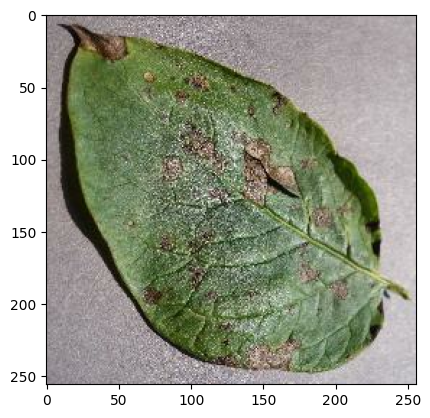

In [31]:
#prediction on sample image

import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict: ")
    plt.imshow(first_image)
    print("actual label: ", class_name[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label: ", class_name[np.argmax(batch_prediction[0])])
    
    

In [32]:
# function for interferance

def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)
    
    predictions = model.predict(img_array)
    
    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    
    return predicted_class, confidence

1/1 [==============================] - 0s 16ms/step


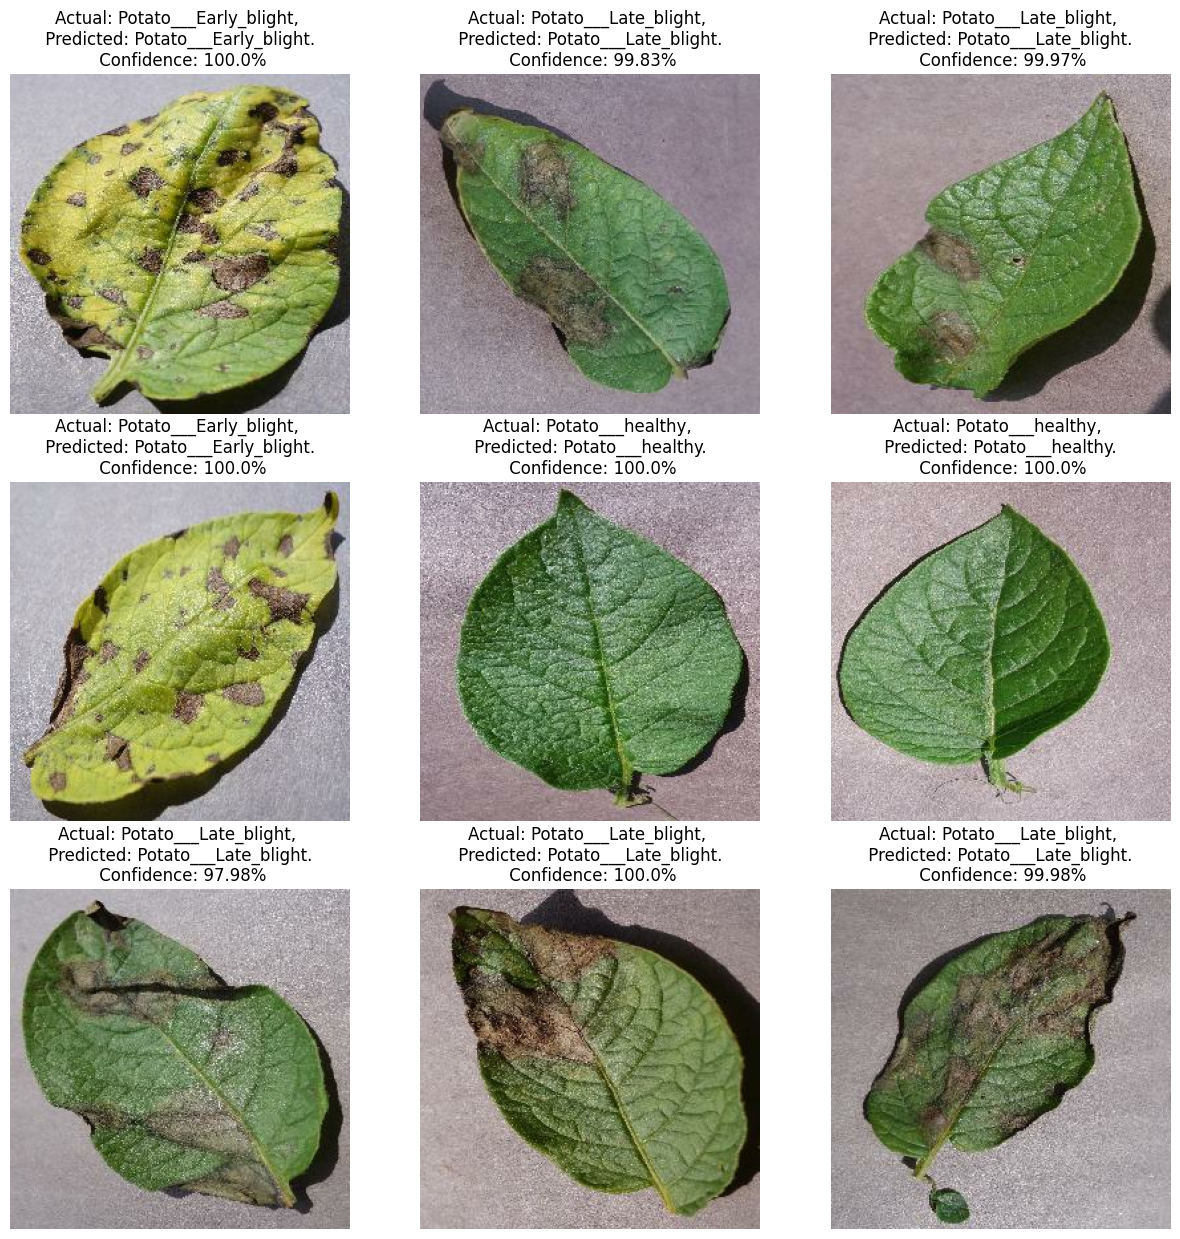

In [33]:
plt.figure(figsize = (15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_name[labels[i]]
        
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}. \n Confidence: {confidence}%")
        plt.axis("off")

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

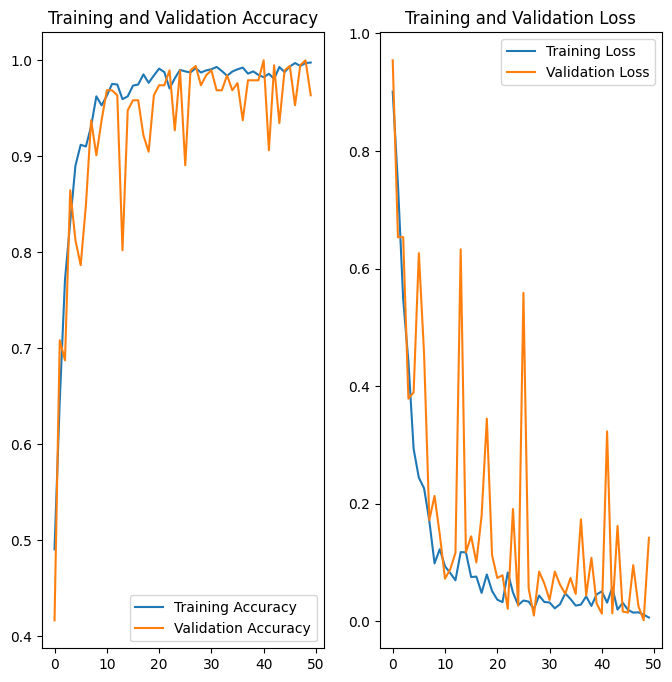

In [35]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Model Saving

In [38]:
import os
model_version = max(int(i) for i in os.listdir("../models") + [0]) + 1
model.save(f"../models/{model_version}")

In [39]:
model.save("../potatoes.h5")